# Day 32: Similarity-Based Product Recommendation Engine
Personalizing product suggestions based on customer similarity (User-User Collaborative Filtering).


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10


## 2. Generate and Load Dataset

In [2]:
# Define products list
products_list = [
    # Electronics
    {"product_id": "P01", "product_name": "Wireless Noise-Canceling Headphones", "category": "Electronics"},
    {"product_id": "P02", "product_name": "Mechanical Gaming Keyboard", "category": "Electronics"},
    {"product_id": "P03", "product_name": "UltraWide 34-inch Gaming Monitor", "category": "Electronics"},
    {"product_id": "P04", "product_name": "Ergonomic Wireless Mouse", "category": "Electronics"},
    {"product_id": "P05", "product_name": "Smart Fitness Watch", "category": "Electronics"},
    {"product_id": "P06", "product_name": "Portable Bluetooth Speaker", "category": "Electronics"},
    {"product_id": "P07", "product_name": "1080p Webcam with Ring Light", "category": "Electronics"},
    {"product_id": "P08", "product_name": "USB-C Multi-Port Hub Adapter", "category": "Electronics"},
    {"product_id": "P09", "product_name": "External 2TB SSD Hard Drive", "category": "Electronics"},
    {"product_id": "P10", "product_name": "MagSafe Wireless Charging Pad", "category": "Electronics"},
    {"product_id": "P11", "product_name": "Smart Home LED Bulb Pack", "category": "Electronics"},
    {"product_id": "P12", "product_name": "Noise-Isolating In-Ear Earbuds", "category": "Electronics"},
    
    # Books
    {"product_id": "P13", "product_name": "Designing Data-Intensive Applications", "category": "Books"},
    {"product_id": "P14", "product_name": "Atomic Habits by James Clear", "category": "Books"},
    {"product_id": "P15", "product_name": "The Hobbit by J.R.R. Tolkien", "category": "Books"},
    {"product_id": "P16", "product_name": "Python Data Science Handbook", "category": "Books"},
    {"product_id": "P17", "product_name": "Thinking, Fast and Slow by D. Kahneman", "category": "Books"},
    {"product_id": "P18", "product_name": "Sapiens: A Brief History of Humankind", "category": "Books"},
    {"product_id": "P19", "product_name": "Educated: A Memoir by Tara Westover", "category": "Books"},
    {"product_id": "P20", "product_name": "Deep Work by Cal Newport", "category": "Books"},
    {"product_id": "P21", "product_name": "Zero to One by Peter Thiel", "category": "Books"},
    {"product_id": "P22", "product_name": "Introduction to Linear Algebra (Strang)", "category": "Books"},
    {"product_id": "P23", "product_name": "The Clean Coder by Robert C. Martin", "category": "Books"},
    {"product_id": "P24", "product_name": "Dune by Frank Herbert", "category": "Books"},
    
    # Clothing
    {"product_id": "P25", "product_name": "Classic Fit Cotton Crewneck T-Shirt", "category": "Clothing"},
    {"product_id": "P26", "product_name": "Slim-Fit Stretch Denim Jeans", "category": "Clothing"},
    {"product_id": "P27", "product_name": "Lightweight Waterproof Windbreaker", "category": "Clothing"},
    {"product_id": "P28", "product_name": "Running Sneaker Athletic Shoes", "category": "Clothing"},
    {"product_id": "P29", "product_name": "Genuine Leather Casual Belt", "category": "Clothing"},
    {"product_id": "P30", "product_name": "Cozy Knit Crewneck Sweater", "category": "Clothing"},
    {"product_id": "P31", "product_name": "Polarized Sports Sunglasses", "category": "Clothing"},
    {"product_id": "P32", "product_name": "Breathable Mesh Workout Socks (6 Pack)", "category": "Clothing"},
    {"product_id": "P33", "product_name": "Fleece Hooded Sweatshirt", "category": "Clothing"},
    {"product_id": "P34", "product_name": "Quick-Dry Swim Trunks", "category": "Clothing"},
    {"product_id": "P35", "product_name": "Canvas Travel Duffel Bag", "category": "Clothing"},
    {"product_id": "P36", "product_name": "Warm Wool Winter Beanie", "category": "Clothing"},
    
    # Home & Kitchen
    {"product_id": "P37", "product_name": "Stainless Steel Electric Kettle", "category": "Home & Kitchen"},
    {"product_id": "P38", "product_name": "Non-Stick Ceramic Frying Pan", "category": "Home & Kitchen"},
    {"product_id": "P39", "product_name": "Memory Foam Sleep Pillow", "category": "Home & Kitchen"},
    {"product_id": "P40", "product_name": "Aromatherapy Essential Oil Diffuser", "category": "Home & Kitchen"},
    {"product_id": "P41", "product_name": "Double-Wall Insulated Coffee Mug", "category": "Home & Kitchen"},
    {"product_id": "P42", "product_name": "Magnetic Knife Strip Holder", "category": "Home & Kitchen"},
    {"product_id": "P43", "product_name": "Digital Food Kitchen Scale", "category": "Home & Kitchen"},
    {"product_id": "P44", "product_name": "Modern Matte Ceramic Dinnerware Set", "category": "Home & Kitchen"},
    {"product_id": "P45", "product_name": "Airtight Glass Food Storage Jars", "category": "Home & Kitchen"},
    {"product_id": "P46", "product_name": "Silicone Cooking Utensils Set (12 pcs)", "category": "Home & Kitchen"},
    {"product_id": "P47", "product_name": "Premium Cotton Bed Sheet Set", "category": "Home & Kitchen"},
    {"product_id": "P48", "product_name": "Rechargeable Cordless Handheld Vacuum", "category": "Home & Kitchen"},
    
    # Sports & Outdoors
    {"product_id": "P49", "product_name": "High-Density Yoga Mat with Carrying Strap", "category": "Sports & Outdoors"},
    {"product_id": "P50", "product_name": "Insulated Stainless Steel Water Bottle", "category": "Sports & Outdoors"},
    {"product_id": "P51", "product_name": "Adjustable Dumbbell Set (Pair)", "category": "Sports & Outdoors"},
    {"product_id": "P52", "product_name": "Heavy-Duty Resistance Band Set", "category": "Sports & Outdoors"},
    {"product_id": "P53", "product_name": "Ultralight Camping Backpacking Tent", "category": "Sports & Outdoors"},
    {"product_id": "P54", "product_name": "Self-Inflating Sleeping Pad", "category": "Sports & Outdoors"},
    {"product_id": "P55", "product_name": "Folding Aluminum Camp Table", "category": "Sports & Outdoors"},
    {"product_id": "P56", "product_name": "Ergonomic Trekking Hiking Poles", "category": "Sports & Outdoors"},
    {"product_id": "P57", "product_name": "Speed Jump Rope with Ball Bearings", "category": "Sports & Outdoors"},
    {"product_id": "P58", "product_name": "Deep Tissue Muscle Massage Gun", "category": "Sports & Outdoors"},
    {"product_id": "P59", "product_name": "Waterproof Outdoor Picnic Blanket", "category": "Sports & Outdoors"},
    {"product_id": "P60", "product_name": "UV Protection Cooling Arm Sleeves", "category": "Sports & Outdoors"}
]

products = pd.DataFrame(products_list)
products.to_csv("products.csv", index=False)

np.random.seed(42)
num_customers = 300
archetypes = ["Electronics", "Books", "Clothing", "Home & Kitchen", "Sports & Outdoors"]
customer_profiles = []

for i in range(num_customers):
    cust_id = f"C{i+1:03d}"
    archetype = archetypes[i % len(archetypes)]
    customer_profiles.append({"customer_id": cust_id, "archetype": archetype})

customer_profiles_df = pd.DataFrame(customer_profiles)

ratings_list = []
for _, cust in customer_profiles_df.iterrows():
    cust_id = cust["customer_id"]
    fav_cat = cust["archetype"]
    for _, prod in products.iterrows():
        prod_id = prod["product_id"]
        prod_cat = prod["category"]
        if prod_cat == fav_cat:
            if np.random.rand() < 0.80:
                rating = int(np.clip(np.round(np.random.normal(4.4, 0.6)), 1, 5))
                ratings_list.append({"customer_id": cust_id, "product_id": prod_id, "rating": rating})
        else:
            if np.random.rand() < 0.15:
                rating = int(np.clip(np.round(np.random.normal(2.8, 1.0)), 1, 5))
                ratings_list.append({"customer_id": cust_id, "product_id": prod_id, "rating": rating})

ratings = pd.DataFrame(ratings_list)
ratings.to_csv("customer_ratings.csv", index=False)

n_users = ratings['customer_id'].nunique()
n_items = ratings['product_id'].nunique()
n_ratings = len(ratings)
sparsity = (1 - n_ratings / (n_users * n_items)) * 100

print(f"Unique Customers: {n_users}")
print(f"Unique Products: {n_items}")
print(f"Total Ratings: {n_ratings}")
print(f"Sparsity: {sparsity:.2f}%")


Unique Customers: 300
Unique Products: 60
Total Ratings: 4999
Sparsity: 72.23%


### EDA: Distributions

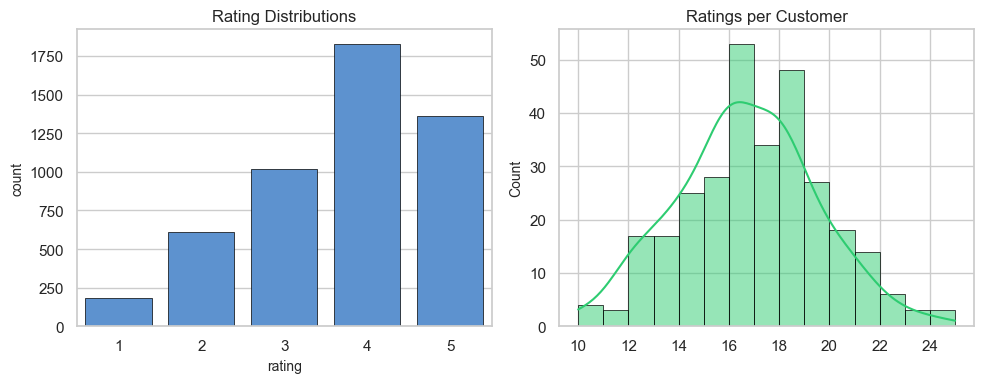

In [3]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(data=ratings, x='rating', color='#4A90E2', edgecolor='black', linewidth=0.5)
plt.title('Rating Distributions')

plt.subplot(1, 2, 2)
ratings_per_customer = ratings.groupby('customer_id').size()
sns.histplot(ratings_per_customer, bins=15, kde=True, color='#2ECC71', edgecolor='black', linewidth=0.5)
plt.title('Ratings per Customer')

plt.tight_layout()
plt.savefig('rating_distributions.png', dpi=150)
plt.show()


## 3. Pivot User-Item Matrix

In [4]:
R = ratings.pivot(index='customer_id', columns='product_id', values='rating')
print("Matrix shape:", R.shape)
R.iloc[:5, :8]


Matrix shape: (300, 60)


product_id,P01,P02,P03,P04,P05,P06,P07,P08
customer_id,,,,,,,,
C001,4.0,5.0,5.0,5.0,4.0,4.0,3.0,5.0
C002,NaN,NaN,NaN,NaN,4.0,3.0,NaN,NaN
C003,4.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN
C004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C005,NaN,NaN,NaN,NaN,NaN,NaN,3.0,5.0


## 4. Calculate Customer Similarity

In [5]:
# 1. Cosine similarity
cosine_sim = cosine_similarity(R.fillna(0))
cosine_sim_df = pd.DataFrame(cosine_sim, index=R.index, columns=R.index)

# 2. Pearson correlation
pearson_sim_df = R.T.corr(method='pearson')

print("Pearson Similarity Preview:")
print(pearson_sim_df.iloc[:5, :5].round(3))


Pearson Similarity Preview:
customer_id   C001   C002   C003   C004   C005
customer_id                                   
C001         1.000 -0.488 -0.304  0.316 -0.050
C002        -0.488  1.000 -0.756 -0.333 -1.000
C003        -0.304 -0.756  1.000 -1.000 -0.945
C004         0.316 -0.333 -1.000  1.000  0.500
C005        -0.050 -1.000 -0.945  0.500  1.000


### Visualize Similarity Heatmap (First 25 Customers)

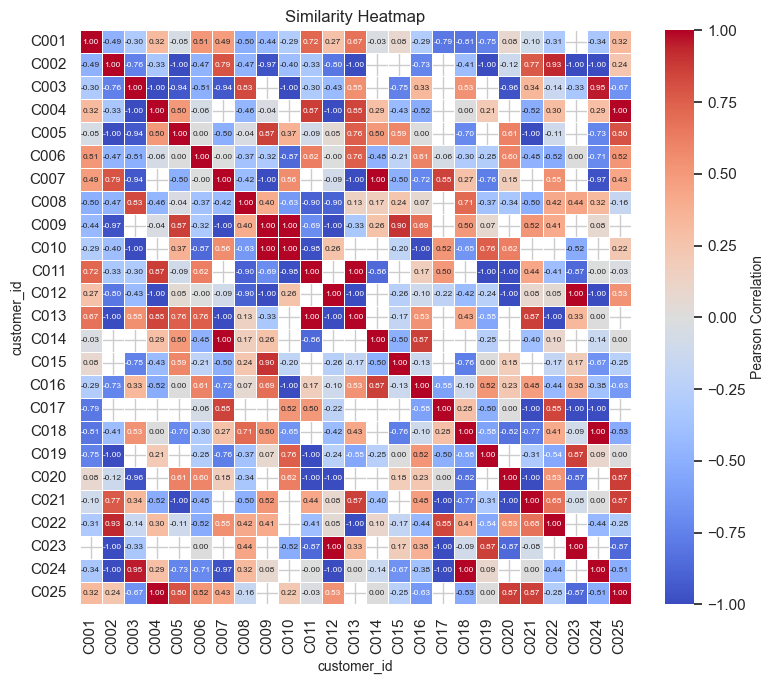

In [6]:
plt.figure(figsize=(8, 7))
sns.heatmap(
    pearson_sim_df.iloc[:25, :25],
    cmap='coolwarm',
    vmin=-1.0,
    vmax=1.0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation'}
)
plt.title('Similarity Heatmap')
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150)
plt.show()


## 5. Predict Ratings & Recommend Products

In [7]:
user_means = R.mean(axis=1)
R_centered = R.sub(user_means, axis=0)

def predict_rating(user_id, product_id, R_matrix, R_centered_matrix, similarity_df, user_means_series, K=10):
    if product_id not in R_matrix.columns:
        return user_means_series.get(user_id, 3.0)
    if user_id not in R_matrix.index:
        return R_matrix[product_id].mean()
        
    other_raters = R_matrix[product_id].dropna().index
    other_raters = other_raters.drop(user_id) if user_id in other_raters else other_raters
    
    if len(other_raters) == 0:
        return user_means_series[user_id]
        
    sim_scores = similarity_df.loc[user_id, other_raters].dropna()
    sim_scores = sim_scores[sim_scores > 0]
    
    if len(sim_scores) == 0:
        return user_means_series[user_id]
        
    top_neighbors = sim_scores.nlargest(K)
    neighbor_ids = top_neighbors.index
    
    neighbor_centered_ratings = R_centered_matrix.loc[neighbor_ids, product_id]
    numerator = np.sum(top_neighbors * neighbor_centered_ratings)
    denominator = np.sum(np.abs(top_neighbors))
    
    if denominator == 0:
        return user_means_series[user_id]
        
    return np.clip(user_means_series[user_id] + (numerator / denominator), 1.0, 5.0)

def recommend_products(user_id, R_matrix, R_centered_matrix, similarity_df, user_means_series, products_df, top_n=5, K=10):
    user_ratings = R_matrix.loc[user_id]
    unrated_products = user_ratings[user_ratings.isna()].index
    
    predictions = []
    for prod_id in unrated_products:
        pred_rating = predict_rating(user_id, prod_id, R_matrix, R_centered_matrix, similarity_df, user_means_series, K=K)
        predictions.append((prod_id, pred_rating))
        
    pred_df = pd.DataFrame(predictions, columns=['product_id', 'predicted_rating'])
    recs = pred_df.merge(products_df, on='product_id')
    return recs.sort_values(by='predicted_rating', ascending=False).head(top_n)

# Quick recommendation demo
demo_users = {"C001": "Tech Enthusiast", "C061": "Bookworm"}
for uid, name in demo_users.items():
    print(f"\nRecommendations for {uid} ({name}):")
    recs = recommend_products(uid, R, R_centered, pearson_sim_df, user_means, products, top_n=3, K=10)
    for idx, row in recs.reset_index(drop=True).iterrows():
        print(f" - {row['product_name']} ({row['category']}) | Predicted: {row['predicted_rating']:.2f}")



Recommendations for C001 (Tech Enthusiast):
 - High-Density Yoga Mat with Carrying Strap (Sports & Outdoors) | Predicted: 4.21
 - Warm Wool Winter Beanie (Clothing) | Predicted: 4.19
 - Classic Fit Cotton Crewneck T-Shirt (Clothing) | Predicted: 4.02

Recommendations for C061 (Bookworm):
 - MagSafe Wireless Charging Pad (Electronics) | Predicted: 4.38
 - Wireless Noise-Canceling Headphones (Electronics) | Predicted: 4.28
 - Airtight Glass Food Storage Jars (Home & Kitchen) | Predicted: 4.25


## 6. Evaluation of Recommendations

In [8]:
# Split ratings 80/20 by masking
np.random.seed(42)
R_train = R.copy()
non_null_coords = []
for u in R.index:
    for i in R.loc[u].dropna().index:
        non_null_coords.append((u, i, R.loc[u, i]))

n_mask = int(len(non_null_coords) * 0.20)
shuffled_indices = np.random.permutation(len(non_null_coords))
mask_coords = [non_null_coords[idx] for idx in shuffled_indices[:n_mask]]

test_ratings = []
for u, i, r in mask_coords:
    R_train.loc[u, i] = np.nan
    test_ratings.append({'customer_id': u, 'product_id': i, 'actual_rating': r})

test_df = pd.DataFrame(test_ratings)
print(f"Masked {len(test_df)} test ratings.")


Masked 999 test ratings.

In [9]:
def evaluate(R_tr, test_data, products_df, k_values=[2, 5, 10, 15, 20, 30]):
    user_means_tr = R_tr.mean(axis=1)
    R_centered_tr = R_tr.sub(user_means_tr, axis=0)
    pearson_sim_tr = R_tr.T.corr(method='pearson')
    np.fill_diagonal(pearson_sim_tr.values, 1.0)
    
    results = []
    for K in k_values:
        predictions, actuals = [], []
        for _, row in test_data.iterrows():
            uid, pid, act = row['customer_id'], row['product_id'], row['actual_rating']
            pred = predict_rating(uid, pid, R_tr, R_centered_tr, pearson_sim_tr, user_means_tr, K=K)
            predictions.append(pred)
            actuals.append(act)
            
        rmse = np.sqrt(np.mean((np.array(actuals) - np.array(predictions))**2))
        mae = np.mean(np.abs(np.array(actuals) - np.array(predictions)))
        
        # Calculate Precision@5 & Recall@5 (Actual rating >= 4 is 'liked')
        precisions, recalls = [], []
        test_by_user = test_data.groupby('customer_id')
        for uid, group in test_by_user:
            rel_items = set(group[group['actual_rating'] >= 4.0]['product_id'])
            if not rel_items:
                continue
            recs = recommend_products(uid, R_tr, R_centered_tr, pearson_sim_tr, user_means_tr, products_df, top_n=5, K=K)
            rec_items = set(recs['product_id'])
            hits = len(rec_items.intersection(rel_items))
            precisions.append(hits / 5.0)
            recalls.append(hits / len(rel_items))
            
        results.append({
            'K': K, 'RMSE': rmse, 'MAE': mae, 
            'Precision@5': np.mean(precisions), 'Recall@5': np.mean(recalls)
        })
    return pd.DataFrame(results)

eval_df = evaluate(R_train, test_df, products)
eval_df.to_csv("evaluation_results.csv", index=False)
eval_df


,K,RMSE,MAE,Precision@5,Recall@5
0,2,1.411200,1.140014,0.049254,0.094172
1,5,1.241523,1.000181,0.069403,0.145940
2,10,1.110284,0.885142,0.135821,0.284657
3,15,1.079010,0.850993,0.172388,0.372166
4,20,1.069808,0.840558,0.177612,0.395176
5,30,1.066172,0.837650,0.182836,0.406770


### Plot Evaluation Metrics

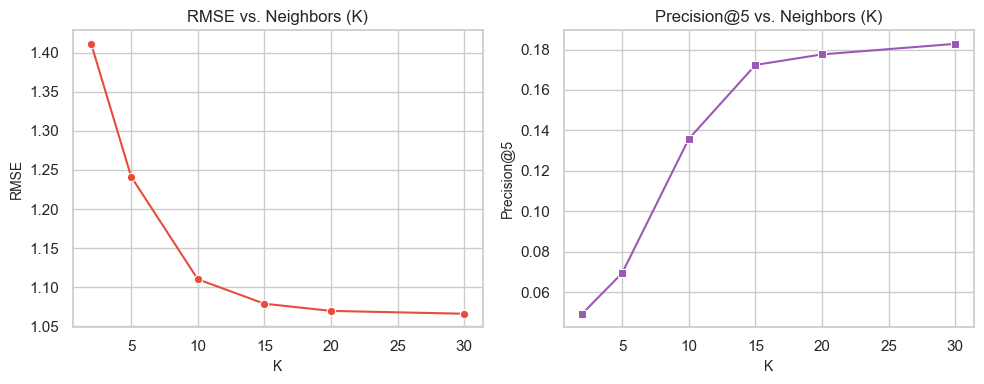

In [10]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.lineplot(data=eval_df, x='K', y='RMSE', marker='o', color='#E74C3C')
plt.title('RMSE vs. Neighbors (K)')

plt.subplot(1, 2, 2)
sns.lineplot(data=eval_df, x='K', y='Precision@5', marker='s', color='#9B59B6')
plt.title('Precision@5 vs. Neighbors (K)')

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150)
plt.show()


## 7. Conclusions & Real-World Personalization Strategies
- **Neighborhood Size ($K$)**: Large K values (e.g. 15-30) lead to lower RMSE and higher Precision here because customer groups are size 60. Very small $K$ creates high variance.
- **Cold Start Mitigation**: Popularity recommendations for new users; content-based similarity fallback using categories/descriptions for new items.
- **Implicit Feedback**: In production, track views, cart adds, clicks instead of explicit ratings, applying frequency-based confidence scoring.
- **Scalability**: For large datasets, compute user similarity offline, use Item-Item Collaborative Filtering, or implement latent vector models (SVD/ALS).
